# Retail Sales & Profitability Analytics — Superstore Dataset

**Goal:** Understand what drives sales and profit in this retail dataset, and turn findings into business recommendations.

**Step 1: Load and explore the data**


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('superstore_raw.csv')

# How big is it, what columns do we have?
print(df.shape)
df.head()


(9994, 21)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2.0,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3.0,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2.0,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,NaN,5.0,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,NaN,2.0,0.20,2.5164


Check data types and non-null counts for every column.

In [2]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9795 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9795 non-null   float64
 18  Quantity       9795

Quick statistical summary of the numeric columns (Sales, Quantity, Discount, Profit).

In [3]:
df.describe()


,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9795.000000,9795.000000,9994.000000,9795.000000
mean,4997.500000,55190.379428,230.257494,3.787034,0.156203,28.735232
std,2885.163629,32063.693350,625.242932,2.225627,0.206452,235.277389
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.725500
50%,4997.500000,56430.500000,54.816000,3.000000,0.200000,8.601600
75%,7495.750000,90008.000000,209.974500,5.000000,0.200000,29.372000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


Check for missing values and duplicate rows.

In [4]:
print("Missing values per column:")
print(df.isnull().sum())

print("\nNumber of duplicate rows:", df.duplicated().sum())


Missing values per column:
Row ID             0
Order ID           0
Order Date         0
Ship Date          0
Ship Mode          0
Customer ID        0
Customer Name      0
Segment            0
Country            0
City               0
State              0
Postal Code        0
Region             0
Product ID         0
Category         199
Sub-Category       0
Product Name       0
Sales            199
Quantity         199
Discount           0
Profit           199
dtype: int64

Number of duplicate rows: 0


## Step 2: Clean the data

**Decision on the 199 missing rows:** Since Category, Sales, Quantity, and Profit are missing together in the same 199 rows, we can't safely guess/impute financial numbers — making up a Sales or Profit value would corrupt the analysis. Since it's only ~2% of the data, we'll drop those rows rather than risk skewing results.


In [5]:
# Drop rows missing core financial data (~2% of rows, unsafe to impute)
df_clean = df.dropna(subset=['Category', 'Sales', 'Quantity', 'Profit']).copy()

print("Before:", df.shape)
print("After: ", df_clean.shape)


Before: (9994, 21)
After:  (9223, 21)


Convert Order Date and Ship Date from text to actual datetime objects, so we can extract month/year and do time-based analysis.

In [6]:
df_clean['Order Date'] = pd.to_datetime(df_clean['Order Date'])
df_clean['Ship Date'] = pd.to_datetime(df_clean['Ship Date'])

df_clean[['Order Date', 'Ship Date']].dtypes


Order Date    datetime64[us]
Ship Date     datetime64[us]
dtype: object

Add derived columns we'll need for analysis: **Profit Margin** (profit as a % of sales), **Order Month** and **Order Year** (for trend analysis), and **Shipping Days** (how long delivery took).

In [7]:
df_clean['Profit Margin'] = df_clean['Profit'] / df_clean['Sales']
df_clean['Order Month'] = df_clean['Order Date'].dt.month
df_clean['Order Year'] = df_clean['Order Date'].dt.year
df_clean['Shipping Days'] = (df_clean['Ship Date'] - df_clean['Order Date']).dt.days

df_clean[['Sales', 'Profit', 'Profit Margin', 'Order Month', 'Order Year', 'Shipping Days']].head()


,Sales,Profit,Profit Margin,Order Month,Order Year,Shipping Days
0,261.96,41.9136,0.16,11,2016,3
1,731.94,219.5820,0.30,11,2016,3
2,14.62,6.8714,0.47,6,2016,4
5,48.86,14.1694,0.29,6,2014,5
6,7.28,1.9656,0.27,6,2014,5


Sanity check: does Profit Margin make sense? Look at its distribution — are there extreme outliers we should know about before analyzing?

In [8]:
df_clean['Profit Margin'].describe()


count    9223.000000
mean        0.121289
std         0.464856
min        -2.750000
25%         0.075000
50%         0.270000
75%         0.362500
max         0.500000
Name: Profit Margin, dtype: float64

Save the cleaned dataset so Step 3 can load it directly.

In [9]:
df_clean.to_csv('superstore_clean.csv', index=False)
print("Saved cleaned dataset:", df_clean.shape)


Saved cleaned dataset: (9223, 25)


## Step 3: Answer business questions with groupby analysis

Load the cleaned data and start asking real questions of it.


In [10]:
df = pd.read_csv('superstore_clean.csv')
df['Order Date'] = pd.to_datetime(df['Order Date'])
df.shape


(9223, 25)

### Q1: Which regions are most and least profitable?

`groupby('Region')` groups all rows by region, then `.sum()` adds up Sales and Profit within each group.


In [11]:
region_profit = df.groupby('Region')[['Sales', 'Profit']].sum().sort_values('Profit', ascending=False)
region_profit['Profit Margin %'] = (region_profit['Profit'] / region_profit['Sales'] * 100).round(1)
region_profit


,Sales,Profit,Profit Margin %
Region,,,
West,673416.6510,100862.2198,15.0
East,622284.4160,80810.1998,13.0
South,365755.7195,44912.2920,12.3
Central,461702.9676,34502.4946,7.5


### Q2: Which Category / Sub-Category makes money, and which loses money?

Group by both Category and Sub-Category together to see the full breakdown.


In [12]:
cat_profit = df.groupby(['Category', 'Sub-Category'])[['Sales', 'Profit']].sum().sort_values('Profit')
cat_profit


Sales      Profit
Category        Sub-Category                         
Furniture       Tables        187730.8295 -15871.4525
                Bookcases     105552.2076  -3052.3703
Technology      Machines      173118.6650  -1418.5040
Office Supplies Supplies       46427.0180  -1226.2535
                Fasteners       2954.9580    925.0114
                Labels         11760.8300   5209.1317
                Art            24647.9120   5884.9514
                Envelopes      14654.1180   6160.5038
Furniture       Furnishings    84724.2920  11851.0992
Office Supplies Appliances     97257.5510  15825.1717
                Storage       206364.6780  19234.4187
Furniture       Chairs        300416.4940  23025.5554
Office Supplies Binders       191533.5210  30848.3634
                Paper          72941.6480  31594.0563
Technology      Accessories   158704.7280  39609.1611
                Phones        306242.0600  41133.4645
                Copiers       138128.2440  51354.8979

### Q3: Does higher discount actually cause lower profit margin?

We suspected this from the Appliances example earlier. Let's check it properly across the whole dataset by grouping orders into discount bands.


In [13]:
# Group orders into discount bands: 0%, 1-20%, 21-40%, 41-60%, 61-80%, 81-100%
df['Discount Band'] = pd.cut(df['Discount'], bins=[-0.01, 0, 0.2, 0.4, 0.6, 0.8, 1.0],
                              labels=['0%', '1-20%', '21-40%', '41-60%', '61-80%', '81-100%'])

discount_analysis = df.groupby('Discount Band', observed=True).agg(
    orders=('Discount', 'count'),
    avg_profit_margin=('Profit Margin', 'mean')
)
discount_analysis['avg_profit_margin'] = (discount_analysis['avg_profit_margin'] * 100).round(1)
discount_analysis


,orders,avg_profit_margin
Discount Band,,
0%,4421,34.0
1-20%,3524,17.4
21-40%,428,-16.8
41-60%,198,-63.6
61-80%,652,-122.7


### Q4: What's the monthly sales trend over time?

Group by Year and Month to see seasonality or growth/decline.


In [14]:
monthly_sales = df.groupby(['Order Year', 'Order Month'])['Sales'].sum()
monthly_sales.tail(12)


Order Year  Order Month
2017        1               41460.4040
            2               19064.1454
            3               57385.5488
            4               34675.5961
            5               40411.4072
            6               46790.8817
            7               40747.0540
            8               58272.1240
            9               77297.9300
            10              74074.2002
            11             111463.5710
            12              77342.7798
Name: Sales, dtype: float64

### Q5: Which customer Segment is most valuable?


In [15]:
segment_analysis = df.groupby('Segment')[['Sales', 'Profit']].sum()
segment_analysis['Profit Margin %'] = (segment_analysis['Profit'] / segment_analysis['Sales'] * 100).round(1)
segment_analysis.sort_values('Profit', ascending=False)


,Sales,Profit,Profit Margin %
Segment,,,
Consumer,1.071572e+06,125370.1704,11.7
Corporate,6.499564e+05,81182.0999,12.5
Home Office,4.016315e+05,54534.9359,13.6


## Step 4: Turn each finding into a chart

Same findings as Step 3, but visual — this is what you'll actually show in the interview.


In [16]:
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100


### Chart 1: Profit margin by Region — Central lags behind

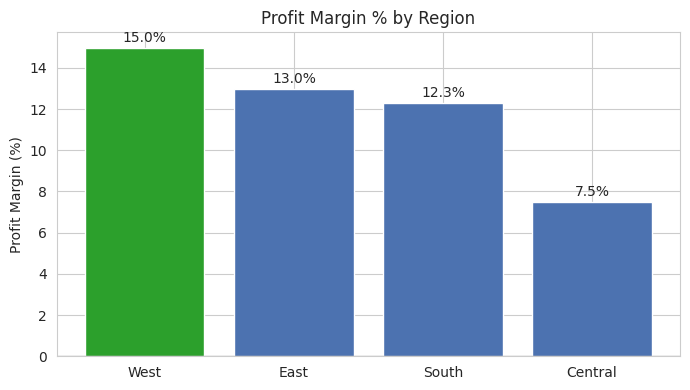

In [17]:
region_profit = df.groupby('Region')[['Sales','Profit']].sum()
region_profit['Margin %'] = region_profit['Profit'] / region_profit['Sales'] * 100
region_profit = region_profit.sort_values('Margin %', ascending=False)

plt.figure(figsize=(7,4))
colors = ['#2ca02c' if v == region_profit['Margin %'].max() else '#4C72B0' for v in region_profit['Margin %']]
plt.bar(region_profit.index, region_profit['Margin %'], color=colors)
plt.title('Profit Margin % by Region')
plt.ylabel('Profit Margin (%)')
plt.axhline(0, color='black', linewidth=0.8)
for i, v in enumerate(region_profit['Margin %']):
    plt.text(i, v + 0.3, f'{v:.1f}%', ha='center')
plt.tight_layout()
plt.savefig('chart1_region_margin.png')
plt.show()


### Chart 2: Which sub-categories make or lose money

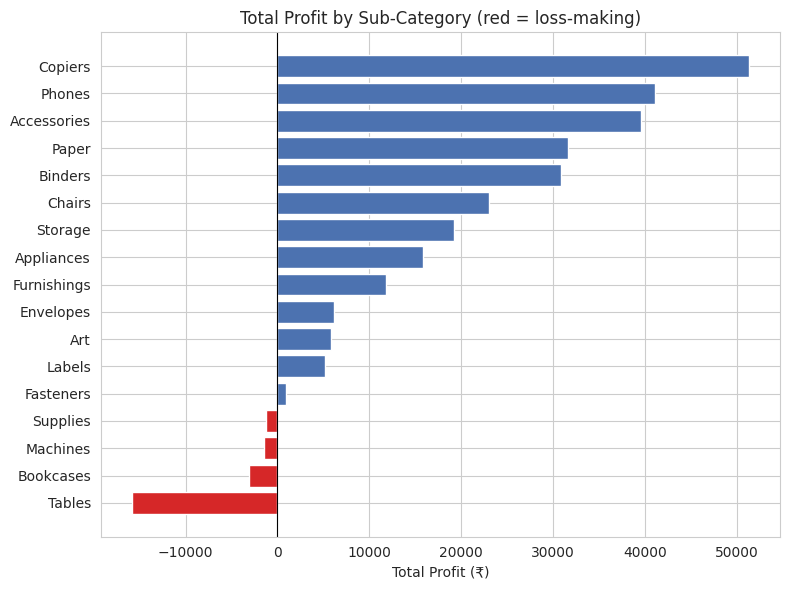

In [18]:
cat_profit = df.groupby('Sub-Category')['Profit'].sum().sort_values()

plt.figure(figsize=(8,6))
colors = ['#d62728' if v < 0 else '#4C72B0' for v in cat_profit]
plt.barh(cat_profit.index, cat_profit.values, color=colors)
plt.title('Total Profit by Sub-Category (red = loss-making)')
plt.xlabel('Total Profit (₹)')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig('chart2_subcategory_profit.png')
plt.show()


### Chart 3: The discount breakpoint — margin collapses past ~20% discount

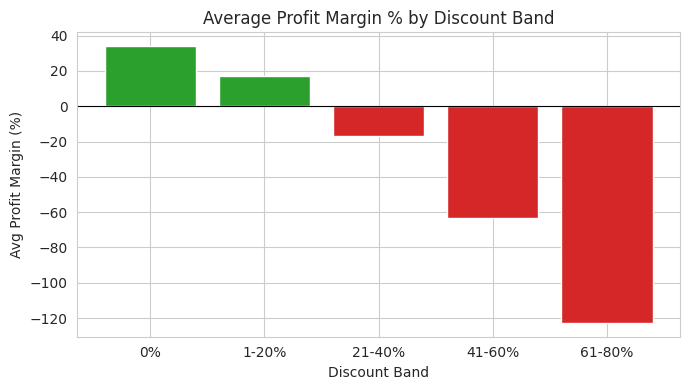

In [19]:
da = df.groupby('Discount Band', observed=True)['Profit Margin'].mean() * 100

plt.figure(figsize=(7,4))
colors = ['#2ca02c' if v >= 0 else '#d62728' for v in da]
plt.bar(da.index.astype(str), da.values, color=colors)
plt.title('Average Profit Margin % by Discount Band')
plt.ylabel('Avg Profit Margin (%)')
plt.xlabel('Discount Band')
plt.axhline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig('chart3_discount_margin.png')
plt.show()


### Chart 4: Monthly sales trend

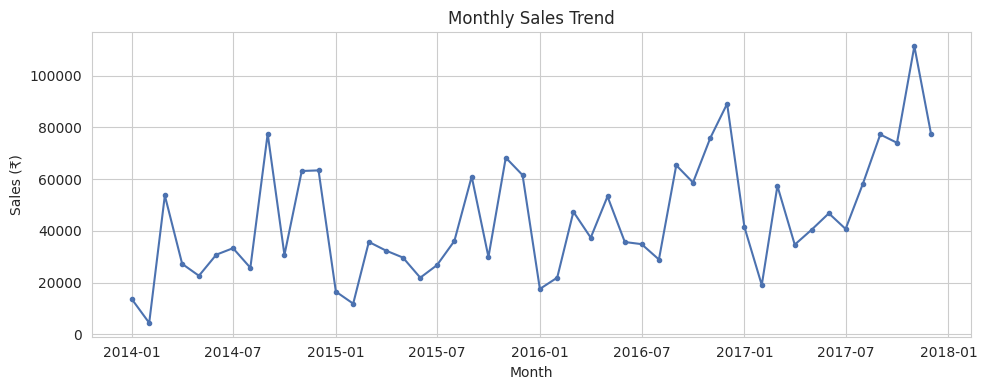

In [20]:
monthly = df.groupby(df['Order Date'].dt.to_period('M'))['Sales'].sum()
monthly.index = monthly.index.to_timestamp()

plt.figure(figsize=(10,4))
plt.plot(monthly.index, monthly.values, marker='o', markersize=3, color='#4C72B0')
plt.title('Monthly Sales Trend')
plt.ylabel('Sales (₹)')
plt.xlabel('Month')
plt.tight_layout()
plt.savefig('chart4_monthly_trend.png')
plt.show()


### Chart 5: Profit margin by Segment

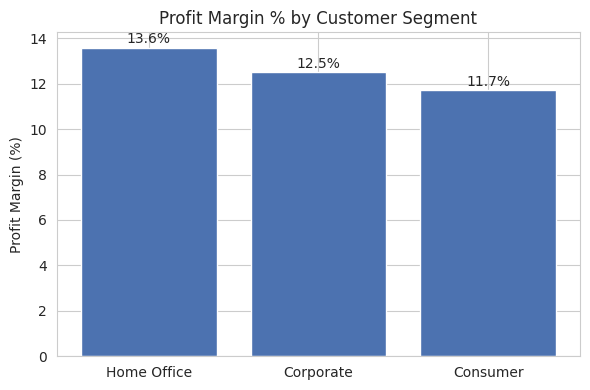

In [21]:
seg = df.groupby('Segment')[['Sales','Profit']].sum()
seg['Margin %'] = seg['Profit'] / seg['Sales'] * 100
seg = seg.sort_values('Margin %', ascending=False)

plt.figure(figsize=(6,4))
plt.bar(seg.index, seg['Margin %'], color='#4C72B0')
plt.title('Profit Margin % by Customer Segment')
plt.ylabel('Profit Margin (%)')
for i, v in enumerate(seg['Margin %']):
    plt.text(i, v + 0.2, f'{v:.1f}%', ha='center')
plt.tight_layout()
plt.savefig('chart5_segment_margin.png')
plt.show()


## Step 5: Business Recommendations

Each finding below is tied directly to a chart from Step 4 — no claim here that isn't backed by a number we actually computed.

---

**1. Cap discounts at 20% (from Chart 3: Discount vs Margin)**
Every discount band above 20% has a *negative* average profit margin, and it gets worse as discount increases — up to -122.7% at 61-80% discount. Recommendation: set a hard discount ceiling around 20%, or require manager approval for anything higher, since the data shows the company loses money past that point on average.

**2. Investigate the Tables sub-category specifically (from Chart 2: Sub-Category Profit)**
Tables lost ₹15,871 overall — by far the biggest loss of any sub-category, more than 5x the next-worst (Bookcases). Recommendation: check whether Tables orders are getting heavier discounts than other Furniture, or whether the cost/pricing on Tables needs to be reworked. This one sub-category is worth a dedicated review.

**3. Study what Central region is doing differently (from Chart 1: Region Margin)**
Central has a 7.5% profit margin, roughly half of West's 15%, despite not being the smallest region by sales. Recommendation: compare Central's discount practices and product mix against West's to find what's dragging margin down — this needs more digging, not just accepting the number.

**4. Protect the Copiers/Phones/Accessories lineup (from Chart 2)**
These three sub-categories are the most profitable by a wide margin. Recommendation: make sure any company-wide discount policy change doesn't accidentally get applied uniformly to these — they're currently propping up the losses elsewhere (like Tables).

**5. Home Office segment is worth more marketing attention (from Chart 5: Segment Margin)**
Home Office has the highest profit margin (13.6%) of the three segments, even though Consumer brings in the most total sales. Recommendation: since Home Office converts revenue to profit most efficiently, it may be worth more targeted marketing spend relative to its current share.

---

**Honest limitation to mention in the interview:** this analysis shows *correlation*, not proof of *causation* — e.g., we know high discounts and negative margins move together, but we haven't ruled out other factors (like which products get discounted, or seasonal clearance sales). With more time, I'd want to check discount reasons before recommending a hard policy change.
